# Sales Forecasting - ARIMA Model Development

This notebook builds and evaluates ARIMA/SARIMA forecasting models.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, str(Path('..').resolve()))

from src.models import (
    calculate_metrics,
    train_test_split_time_series,
    fit_arima,
    fit_sarima,
    grid_search_arima,
    grid_search_sarima,
    create_forecast_dataframe,
)

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Screenshot settings
SCREENSHOTS_DIR = Path('../reports/screenshots')
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)

def save_screenshot(fig, name):
    """Save figure to screenshots directory."""
    filepath = SCREENSHOTS_DIR / f'{name}.png'
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f'Saved: {filepath}')

## 1. Load Data

In [4]:
# Load processed daily sales
df = pd.read_csv('../data/processed/daily_sales_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Use total_sales as our target
series = df['total_sales'].dropna()

print(f"Data shape: {series.shape}")
print(f"Date range: {series.index.min()} to {series.index.max()}")
print(f"Mean sales: £{series.mean():,.2f}")
print(f"Std sales: £{series.std():,.2f}")

Data shape: (305,)
Date range: 2010-12-01 00:00:00 to 2011-12-09 00:00:00
Mean sales: £29,217.73
Std sales: £17,855.00


## 2. Train/Test Split

In [5]:
# Split data (80% train, 20% test)
train, test = train_test_split_time_series(series, test_size=0.2)

print(f"Training set: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test set: {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

Training set: 244 days (2010-12-01 to 2011-09-29)
Test set: 61 days (2011-09-30 to 2011-12-09)


Saved: ../reports/screenshots/04_train_test_split.png


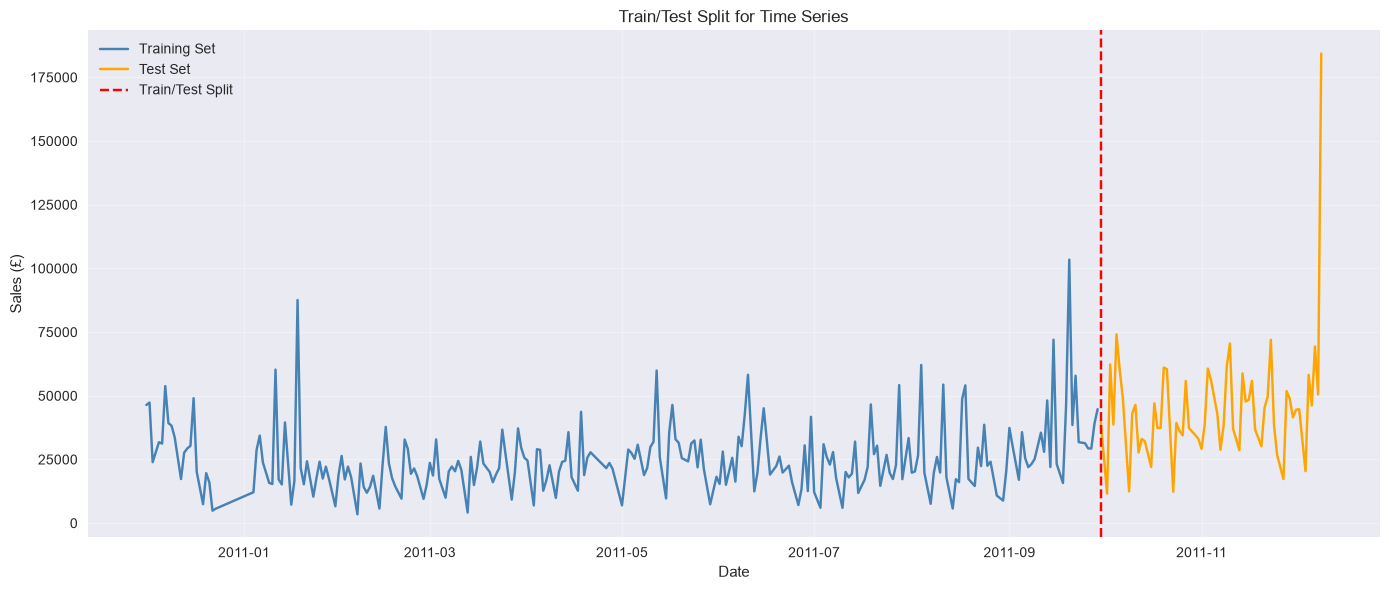

In [6]:
# Plot train/test split
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train.values, label='Training Set', color='steelblue')
ax.plot(test.index, test.values, label='Test Set', color='orange')
ax.axvline(x=test.index[0], color='red', linestyle='--', label='Train/Test Split')

ax.set_xlabel('Date')
ax.set_ylabel('Sales (£)')
ax.set_title('Train/Test Split for Time Series')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_screenshot(fig, '04_train_test_split')
plt.show()

## 3. ARIMA Model

In [7]:
# Fit basic ARIMA(1,1,1)
print("Fitting ARIMA(1,1,1)...")
arima_result = fit_arima(train, order=(1, 1, 1), forecast_steps=len(test))

# Calculate metrics
metrics = calculate_metrics(test.values, arima_result['predictions'].values)

print(f"\nARIMA(1,1,1) Results:")
print(f"AIC: {arima_result['aic']:.2f}")
print(f"BIC: {arima_result['bic']:.2f}")
print(f"MAPE: {metrics['mape']:.2f}%")
print(f"RMSE: £{metrics['rmse']:,.2f}")
print(f"MAE: £{metrics['mae']:,.2f}")

Fitting ARIMA(1,1,1)...

ARIMA(1,1,1) Results:
AIC: 5309.83
BIC: 5320.31
MAPE: 35.51%
RMSE: £24,873.77
MAE: £14,967.03


Saved: ../reports/screenshots/04_arima_forecast.png


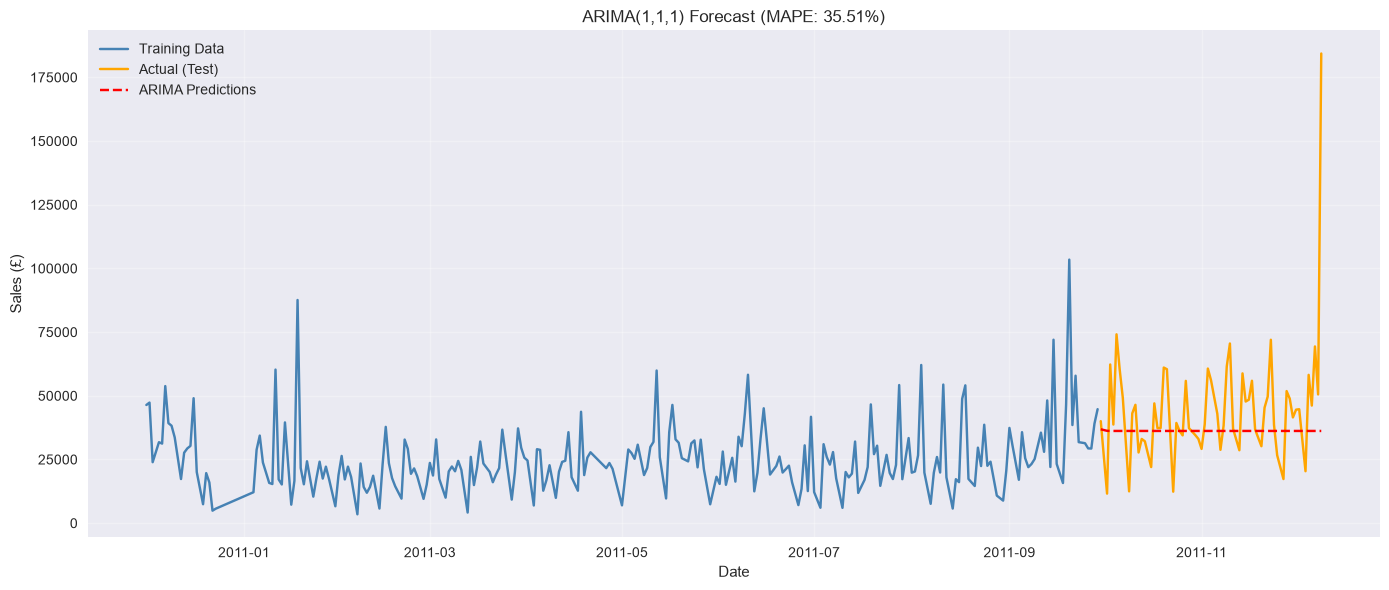

In [8]:
# Plot ARIMA forecast
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train.values, label='Training Data', color='steelblue')
ax.plot(test.index, test.values, label='Actual (Test)', color='orange')
ax.plot(test.index, arima_result['predictions'].values, label='ARIMA Predictions', color='red', linestyle='--')

ax.set_xlabel('Date')
ax.set_ylabel('Sales (£)')
ax.set_title(f'ARIMA(1,1,1) Forecast (MAPE: {metrics["mape"]:.2f}%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_screenshot(fig, '04_arima_forecast')
plt.show()

## 4. ARIMA Grid Search

In [9]:
# Grid search for best ARIMA parameters
print("Running ARIMA grid search...")
arima_results = grid_search_arima(
    train, 
    p_range=range(0, 4),
    d_range=range(0, 2),
    q_range=range(0, 4),
    max_mape=50  # Only keep models with MAPE < 50%
)

print(f"\nFound {len(arima_results)} valid models")
print("\nTop 5 models:")
print("="*70)
for i, result in enumerate(arima_results[:5], 1):
    print(f"{i}. ARIMA{result['order']} - AIC: {result['aic']:.2f}, MAPE: {result['mape']:.2f}%")

Running ARIMA grid search...

Found 32 valid models

Top 5 models:
1. ARIMA(2, 1, 3) - AIC: 4182.60, MAPE: 47.05%
2. ARIMA(3, 1, 3) - AIC: 4184.58, MAPE: 46.49%
3. ARIMA(2, 1, 2) - AIC: 4186.17, MAPE: 46.11%
4. ARIMA(3, 1, 2) - AIC: 4186.71, MAPE: 45.74%
5. ARIMA(1, 1, 2) - AIC: 4186.84, MAPE: 45.51%


In [10]:
# Fit best ARIMA model
best_arima_order = arima_results[0]['order']
print(f"Fitting best ARIMA model: {best_arima_order}")

best_arima = fit_arima(train, order=best_arima_order, forecast_steps=len(test))
best_arima_metrics = calculate_metrics(test.values, best_arima['predictions'].values)

print(f"\nBest ARIMA Results:")
print(f"MAPE: {best_arima_metrics['mape']:.2f}%")
print(f"RMSE: £{best_arima_metrics['rmse']:,.2f}")
print(f"MAE: £{best_arima_metrics['mae']:,.2f}")

Fitting best ARIMA model: (2, 1, 3)

Best ARIMA Results:
MAPE: 35.88%
RMSE: £24,783.07
MAE: £15,003.74


## 5. SARIMA Model (Seasonal)

In [11]:
# Fit SARIMA with weekly seasonality
print("Fitting SARIMA(1,1,1)(1,1,1,7)...")
sarima_result = fit_sarima(
    train, 
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    forecast_steps=len(test)
)

# Calculate metrics
sarima_metrics = calculate_metrics(test.values, sarima_result['predictions'].values)

print(f"\nSARIMA Results:")
print(f"AIC: {sarima_result['aic']:.2f}")
print(f"BIC: {sarima_result['bic']:.2f}")
print(f"MAPE: {sarima_metrics['mape']:.2f}%")
print(f"RMSE: £{sarima_metrics['rmse']:,.2f}")
print(f"MAE: £{sarima_metrics['mae']:,.2f}")

Fitting SARIMA(1,1,1)(1,1,1,7)...

SARIMA Results:
AIC: 5257.99
BIC: 5275.31
MAPE: 42.19%
RMSE: £23,258.17
MAE: £14,639.98


Saved: ../reports/screenshots/04_sarima_forecast.png


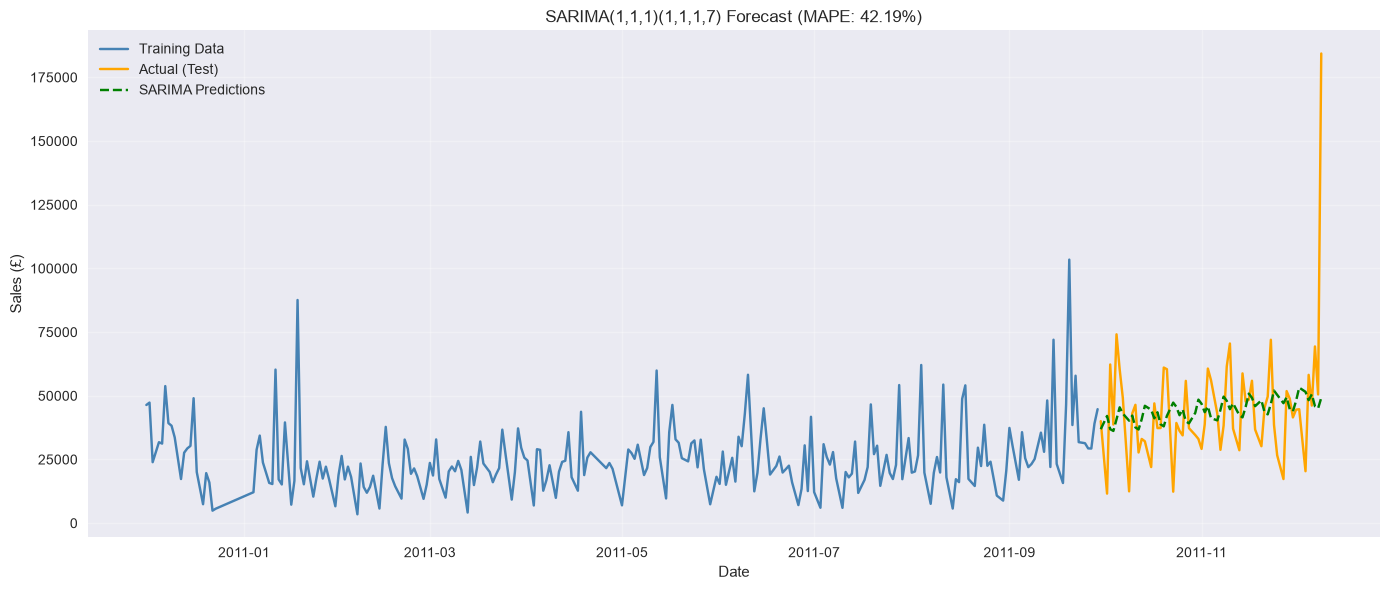

In [12]:
# Plot SARIMA forecast
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train.values, label='Training Data', color='steelblue')
ax.plot(test.index, test.values, label='Actual (Test)', color='orange')
ax.plot(test.index, sarima_result['predictions'].values, label='SARIMA Predictions', color='green', linestyle='--')

ax.set_xlabel('Date')
ax.set_ylabel('Sales (£)')
ax.set_title(f'SARIMA(1,1,1)(1,1,1,7) Forecast (MAPE: {sarima_metrics["mape"]:.2f}%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_screenshot(fig, '04_sarima_forecast')
plt.show()

## 6. Model Comparison

In [13]:
# Compare models
comparison = pd.DataFrame({
    'Model': ['ARIMA(1,1,1)', f'Best ARIMA{best_arima_order}', 'SARIMA(1,1,1)(1,1,1,7)'],
    'MAPE (%)': [metrics['mape'], best_arima_metrics['mape'], sarima_metrics['mape']],
    'RMSE (£)': [metrics['rmse'], best_arima_metrics['rmse'], sarima_metrics['rmse']],
    'MAE (£)': [metrics['mae'], best_arima_metrics['mae'], sarima_metrics['mae']]
})

print("MODEL COMPARISON")
print("="*70)
print(comparison.to_string(index=False))

# Find best model
best_model_idx = comparison['MAPE (%)'].idxmin()
print(f"\nBest Model: {comparison.loc[best_model_idx, 'Model']} (MAPE: {comparison.loc[best_model_idx, 'MAPE (%)']:.2f}%)")

MODEL COMPARISON
                 Model  MAPE (%)     RMSE (£)      MAE (£)
          ARIMA(1,1,1) 35.511988 24873.774950 14967.033219
   Best ARIMA(2, 1, 3) 35.878742 24783.071307 15003.744651
SARIMA(1,1,1)(1,1,1,7) 42.188004 23258.169773 14639.979933

Best Model: ARIMA(1,1,1) (MAPE: 35.51%)


Saved: ../reports/screenshots/04_model_comparison.png


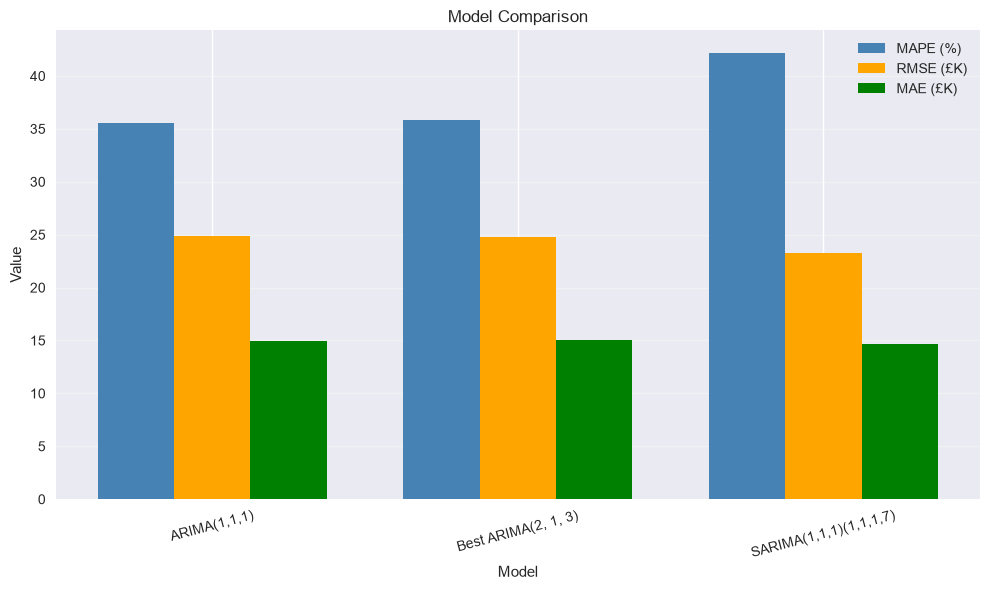

In [14]:
# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison))
width = 0.25

ax.bar(x - width, comparison['MAPE (%)'], width, label='MAPE (%)', color='steelblue')
ax.bar(x, comparison['RMSE (£)'] / 1000, width, label='RMSE (£K)', color='orange')
ax.bar(x + width, comparison['MAE (£)'] / 1000, width, label='MAE (£K)', color='green')

ax.set_xlabel('Model')
ax.set_ylabel('Value')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_screenshot(fig, '04_model_comparison')
plt.show()

## 7. Residual Analysis

Saved: ../reports/screenshots/04_residual_analysis.png


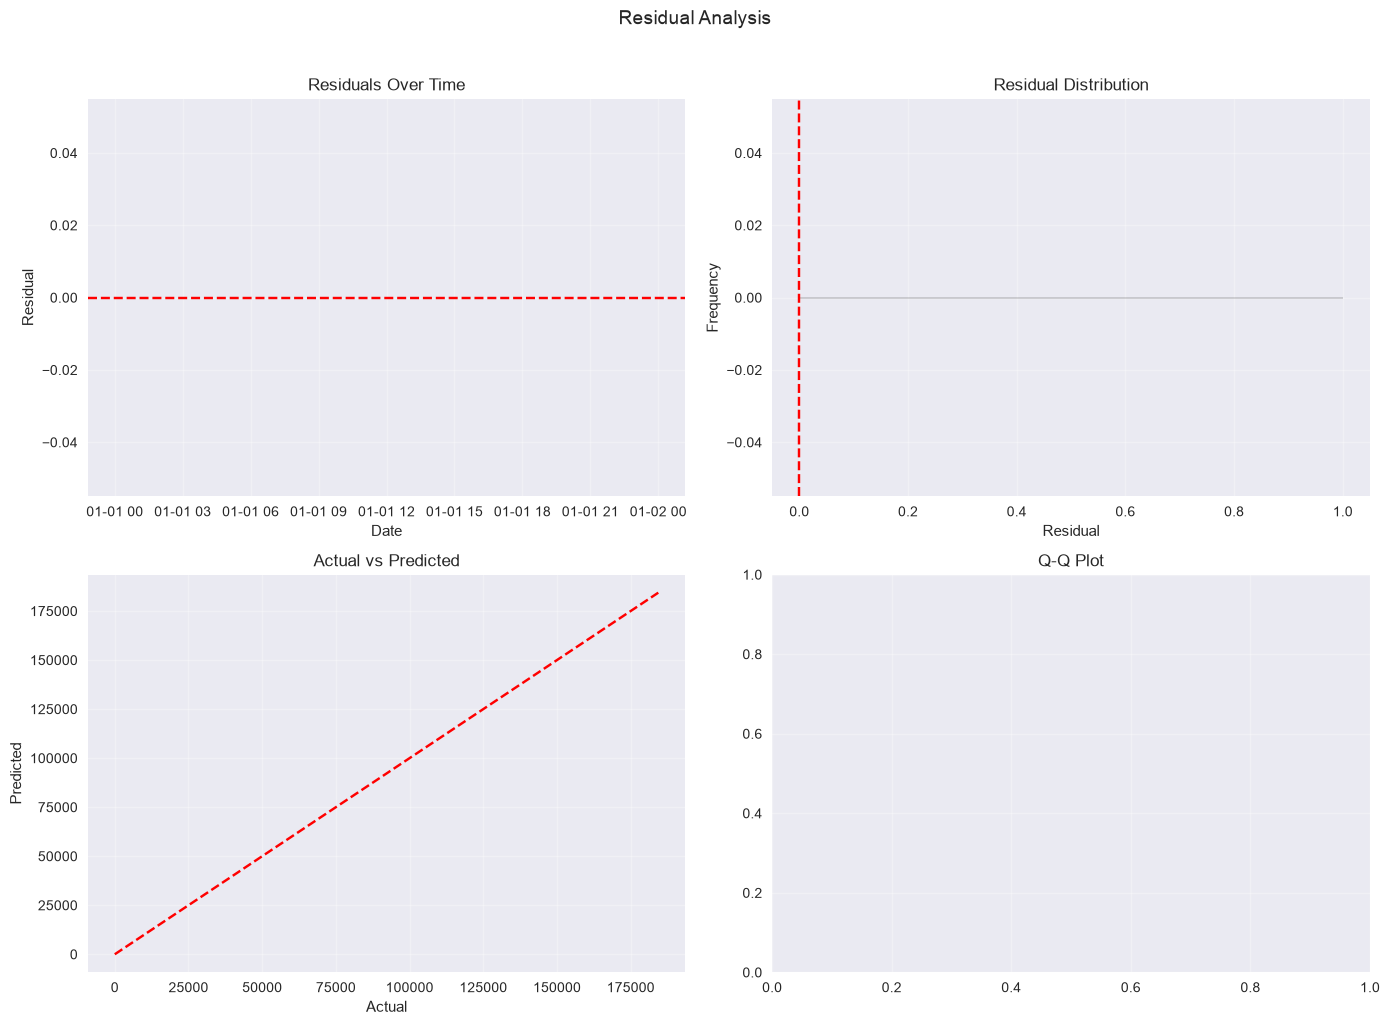

In [15]:
# Use best model for residual analysis
best_predictions = sarima_result['predictions'] if sarima_metrics['mape'] < best_arima_metrics['mape'] else best_arima['predictions']

# Create forecast dataframe
forecast_df = create_forecast_dataframe(series, pd.Series(dtype=float), best_predictions)

# Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals over time
axes[0, 0].plot(forecast_df.index, forecast_df['residual'])
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].grid(True, alpha=0.3)

# Residual distribution
axes[0, 1].hist(forecast_df['residual'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1, 0].scatter(forecast_df['actual'], forecast_df['predicted'], alpha=0.5)
axes[1, 0].plot([0, forecast_df['actual'].max()], [0, forecast_df['actual'].max()], 'r--')
axes[1, 0].set_title('Actual vs Predicted')
axes[1, 0].set_xlabel('Actual')
axes[1, 0].set_ylabel('Predicted')
axes[1, 0].grid(True, alpha=0.3)

# QQ plot
from scipy import stats
stats.probplot(forecast_df['residual'].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis', y=1.02, fontsize=14)
plt.tight_layout()
save_screenshot(fig, '04_residual_analysis')
plt.show()

## 8. Summary

In [16]:
print("="*60)
print("SPRINT 4: ARIMA MODEL DEVELOPMENT SUMMARY")
print("="*60)
print(f"\n1. DATA SPLIT")
print(f"   Training: {len(train)} days")
print(f"   Testing: {len(test)} days")
print(f"\n2. BEST MODEL")
print(f"   {comparison.loc[best_model_idx, 'Model']}")
print(f"   MAPE: {comparison.loc[best_model_idx, 'MAPE (%)']:.2f}%")
print(f"   Target: MAPE ≤ 15%")
if comparison.loc[best_model_idx, 'MAPE (%)'] <= 15:
    print(f"   Status: ✓ TARGET MET")
else:
    print(f"   Status: ✗ Above target")
print(f"\n3. MODEL COMPARISON")
print(comparison.to_string(index=False))
print("="*60)

SPRINT 4: ARIMA MODEL DEVELOPMENT SUMMARY

1. DATA SPLIT
   Training: 244 days
   Testing: 61 days

2. BEST MODEL
   ARIMA(1,1,1)
   MAPE: 35.51%
   Target: MAPE ≤ 15%
   Status: ✗ Above target

3. MODEL COMPARISON
                 Model  MAPE (%)     RMSE (£)      MAE (£)
          ARIMA(1,1,1) 35.511988 24873.774950 14967.033219
   Best ARIMA(2, 1, 3) 35.878742 24783.071307 15003.744651
SARIMA(1,1,1)(1,1,1,7) 42.188004 23258.169773 14639.979933
